<a href="https://colab.research.google.com/github/AdamKovalenko/Traffic-sign-detection-project/blob/main/Road_Sign_ProjectV2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [121]:
!pip install -q inference-sdk opencv-python

In [ ]:
import cv2
import numpy as np
from inference_sdk import InferenceHTTPClient
from google.colab import files
from google.colab.patches import cv2_imshow
import os

API_KEY = "EiGbOJz8ICoeVDL0zugQ"
MODEL_ID = "traffic-sign-detection-vnb4u/18"
CONF_THRESHOLD = 0.15

CLIENT = InferenceHTTPClient(
    api_url="https://detect.roboflow.com",
    api_key=API_KEY
)

In [ ]:
def run_traffic_sign_detection(conf_threshold=0.20, save_output=True):
    print("Upload an image:")
    uploaded = files.upload()

    if not uploaded:
        print("No image uploaded.")
        return

    filename = list(uploaded.keys())[0]
    print(f"Uploaded file: {filename}")

    image = cv2.imread(filename)
    if image is None:
        print("Could not read the image.")
        return

    resized = cv2.resize(image, (640, 640))
    resized_path = "resized_input.jpg"
    cv2.imwrite(resized_path, resized)

    try:
        print("Analyzing image...")

        result = CLIENT.infer(
            resized_path,
            model_id=f"{MODEL_ID}?confidence={conf_threshold}&overlap=0.7&max_detections=50&format=json"
        )

    except Exception as e:
        print(f"Error during inference: {e}")
        return

    predictions = result.get("predictions", [])

    if not predictions:
        print("No traffic signs detected.")
        cv2_imshow(image)
        return


    for pred in predictions:
        x = pred["x"]
        y = pred["y"]
        w = pred["width"]
        h = pred["height"]
        confidence = pred["confidence"]
        label = pred.get("class", "traffic_sign")

        scale_x = image.shape[1] / 640
        scale_y = image.shape[0] / 640

        x *= scale_x
        y *= scale_y
        w *= scale_x
        h *= scale_y

        x0 = int(x - w / 2)
        y0 = int(y - h / 2)
        x1 = int(x + w / 2)
        y1 = int(y + h / 2)

        cv2.rectangle(image, (x0, y0), (x1, y1), (0, 255, 0), 3)

    print(f"Detected {len(predictions)} traffic sign(s).")
    cv2_imshow(image)

    if save_output:
        output_name = "detected_output.jpg"
        cv2.imwrite(output_name, image)
        print(f"Saved output image as: {output_name}")

Upload an image:


Saving noentry2.png to noentry2.png
Uploaded file: noentry2.png
Analyzing image...
Detected 2 traffic sign(s).


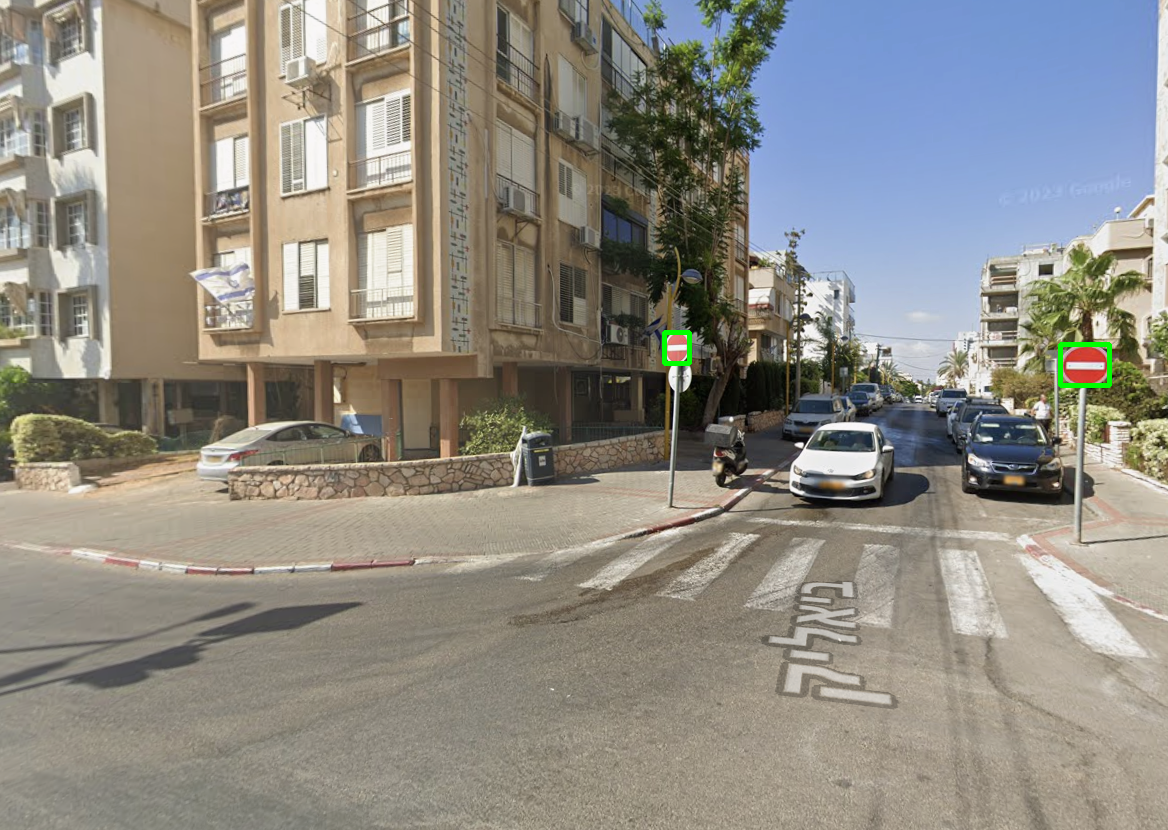

Saved output image as: detected_output.jpg


In [123]:
run_traffic_sign_detection(conf_threshold=CONF_THRESHOLD)